In [ ]:
%pip install ucimlrepo

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, List, Tuple, Dict,Any
"""
    Load the Adult Census Income dataset from UCI repository.
    Reference:
        https://github.com/uci-ml-repo/ucimlrepo/blob/main/src/demo.ipynb
    """
# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# 1. Data Loading 
def load_adult_dataset() -> pd.DataFrame:
    
    adult = fetch_ucirepo(id=2)
    
    if adult.data is None:
        raise ValueError("Failed to fetch dataset from UCI repository.")
    
    # Combine features and targets
    df = pd.concat([adult.data.features, adult.data.targets], axis=1)
    
    return df

#1.1 Explorating dataset function
#Any:any type is acceptable

def explore_dataset(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Returns:
        dict: Summary statistics including column types, shape, etc.
    """
    # Identify column types
    cat_cols = [col for col in df.columns if df[col].dtype == 'object']
    num_cols = [col for col in df.columns if df[col].dtype != 'object']
    
    summary = {
        'shape': df.shape,
        'categorical_columns': cat_cols,
        'numerical_columns': num_cols,
        'total_samples': df.shape[0],
        'total_features': df.shape[1]
    }
    
#Display overview
    print("1. DATASET OVERVIEW")
    display(df.head(10))
    print(f"\nColumn Data Types:")
    print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical columns ({len(num_cols)}): {num_cols}")
    print(f"\nDataset Summary:")
    print(f"Total samples: {summary['total_samples']:,}")
    print(f"Total features: {summary['total_features']}")
    
    return summary

# Load and explore data
df = load_adult_dataset()
dataset_summary = explore_dataset(df)


1. DATASET OVERVIEW


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K



Column Data Types:
Categorical columns (9): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Numerical columns (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Dataset Summary:
Total samples: 48,842
Total features: 15


In [2]:
#get a concise summary of the dataset including data types, non-null counts, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [3]:
#.describe method enable us to detect outliers in the data for further investigation
df.describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


In [4]:
#2. Cleanining missing values on dataset
"""
Clean missing values in the dataset by replacing specified placeholders with NaN.
if found any missing values then drop those rows.
Args:
df: Input DataFrame
    missing_value: Placeholder for missing values (default is '?')
    Returns:
        pd.DataFrame: Cleaned DataFrame with missing values handled
        Reference:
        https://www.geeksforgeeks.org/data-analysis/data-cleansing-introduction/
    """
def analyze_missing_values(df: pd.DataFrame, missing_value: str = '?') -> pd.DataFrame:
    
    print("2. MISSING VALUE ANALYSIS")

    missing_info = []
    
#Check object columns for missing value
    object_cols = df.select_dtypes(include=['object']).columns
    
    for col in object_cols:
        missing_count = (df[col] == missing_value).sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            missing_info.append({
                'column': col,
                'missing_count': missing_count,
                'missing_percentage': missing_pct
            })
#Check for NaN values
    nan_counts = df.isnull().sum()
    if nan_counts.sum() > 0:
        print("\nNaN values found:")
        print(nan_counts[nan_counts > 0])
    
    if not missing_info:
        print("No missing values found.")
        
    return pd.DataFrame(missing_info)

#Analyze missing values
missing_summary = analyze_missing_values(df)
display(missing_summary)  

2. MISSING VALUE ANALYSIS

NaN values found:
workclass         963
occupation        966
native-country    274
dtype: int64


,column,missing_count,missing_percentage
0,workclass,1836,3.759060
1,occupation,1843,3.773392
2,native-country,583,1.193645


In [ ]:
#2.1 Data cleaning functions
"""
Remove columns not needed for demographic market analysis.     
Note:
 Columns removed FOR NOW for paper planner market analysis are:
 - 'fnlwgt': Census sampling weight (not useful for analysis)
 - 'education-num': Duplicate of 'education' column (numerical encoding)
    """

def remove_columns(df: pd.DataFrame, 
                   columns_to_remove: List[str]) -> pd.DataFrame:
   
        return df.drop(columns=columns_to_remove, errors='ignore')


def fix_categorical_inconsistencies(df: pd.DataFrame,
                                     missing_marker: str = '?') -> pd.DataFrame:
    """
    Fixign categorical inconsistencies for the 4 critical demographic variables.
    VANESSA CHECK THIS FUNCTION
    FOCUS: Only clean variables needed for our market analysis hypotheses:
        - age: Digital adoption patterns
        - sex: Gender-specific marketing
        - education: Professional planning needs
        - income: Purchasing power
    PROBLEM: whitespaces, punctuation, and missing values 
    Args: missing_marker: String representing missing values (default: '?')
    """
    # Focus ONLY on the 4 critical demographics for market analysis
    # Only CATEGORICAL demographics need string cleaning
    categorical_demographics = ['sex', 'education', 'income']
    
    for col in categorical_demographics:
        if col not in df.columns:
            continue
        
        # Only clean categorical (object) columns
        if df[col].dtype == 'object':
            # Strip whitespace, replace ?, remove periods
            df[col] = df[col].str.strip()
            df[col] = df[col].replace(missing_marker, np.nan)
            df[col] = df[col].str.rstrip('.')
    
    return df

def impute_missing_critical_demographics(df: pd.DataFrame, strategy: str = 'drop') -> pd.DataFrame:
    """
    Handle missing values in the 4 critical demographic variables.
    Drop rows with ANY missing values to keep only complete records.
    STRATEGY: Drop all rows with missing data
    - No bias from imputed demographic data
    - Accurate income levels 
    """
    critical_demographics = ['age', 'sex', 'education', 'income']
    initial_rows = len(df)
    
    if strategy == 'drop':
        print("••••••• DATA REMOVAL SUMMARY ••••••• \n")
        
        # Check missing values for critical demographics
        for col in critical_demographics:
            if col in df.columns:
                missing_count = df[col].isnull().sum()
                if missing_count > 0:
                    missing_pct = (missing_count / initial_rows) * 100
                    print(f"✗ {col.capitalize()}: {missing_count:,} missing ({missing_pct:.2f}%)")
                else:
                    print(f"• {col.capitalize()}: 0 missing")
        
        # Drop rows with ANY missing values (all columns)
        df = df.dropna()
        
        final_rows = len(df)
        rows_removed = initial_rows - final_rows
        
        print(f"\n✓ Removed {rows_removed:,} rows with missing values")
        print(f"✓ Retained {final_rows:,} complete records ({(final_rows/initial_rows)*100:.1f}%)")
        print(f"{'─' * 80}\n")
    
    return df

def normalize_income(df: pd.DataFrame) -> pd.DataFrame:
    """ This function converts income categories to binary:
        - <=50K → 0 (Lower purchasing power)
        - >50K  → 1 (Higher purchasing power) 
    Business Context: target higher-income 
    """
    if 'income' not in df.columns:
        raise ValueError("Income column not found in dataset")
    
    # Create binary income indicator
    df['income_binary'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)
    
    return df

def remove_duplicates(df: pd.DataFrame) -> Tuple[pd.DataFrame, int]:
    """
    Remove duplicate rows to ensure accurate market sizing.
    
    Returns:
        tuple: (cleaned DataFrame, number of duplicates removed)
    """
    duplicates_count = df.duplicated().sum()
    df_cleaned = df.drop_duplicates()
    
    return df_cleaned, duplicates_count



In [ ]:
# 3. Execute Market-Focused Cleaning Pipeline
### reference: https://github.com/sathishkumarraju/colab-python-data-cleaning-project/blob/main/python_assignment.ipynb

def clean_adult_dataset_for_market_analysis(df: pd.DataFrame, 
                                            columns_to_remove: List[str] = ['fnlwgt', 'education-num']) -> pd.DataFrame:
    
    print("3. DATA CLEANING PIPELINE\n")
   
    # Store initial state
    rows_before = len(df)
    df_cleaned = remove_columns(df, columns_to_remove)
    df_cleaned = fix_categorical_inconsistencies(df_cleaned)
    df_cleaned = impute_missing_critical_demographics(df_cleaned, strategy='drop')
    df_cleaned = normalize_income(df_cleaned)
    df_cleaned, duplicates_removed = remove_duplicates(df_cleaned)
    
    # Calculate 
    rows_after = len(df_cleaned)
    incomplete_removed = rows_before - rows_after - duplicates_removed
    data_retention = (rows_after / rows_before) * 100

    # CLEANED SUMMARY
    print(f" Columns removed: {len(columns_to_remove),} ({columns_to_remove})\n")
    print(f" Duplicates removed: {duplicates_removed:,}\n")
    print(f" Incomplete demographics removed: {incomplete_removed:,}\n")
    print(f" Final market sample: {rows_after:,} individuals\n")
    print(f" Data retention: {data_retention:.2f}% ({rows_after:,} of {rows_before:,} original records)\n")
    
    print("\n•••••••MARKET SEGMENTATION VARIABLES•••••••\n")

    
    if 'age' in df_cleaned.columns:
        print(f"Age:")
        print(f"  • Range: {df_cleaned['age'].min()}-{df_cleaned['age'].max()} years")
        print(f"  • Median: {df_cleaned['age'].median():.0f} years\n")
    
    if 'sex' in df_cleaned.columns:
        gender_dist = df_cleaned['sex'].value_counts()
        print(f"Gender:")
        for gender, count in gender_dist.items():
            pct = count / len(df_cleaned) * 100
            print(f"  • {gender}: {count:,} ({pct:.2f}%)")
        print()
    
    if 'education' in df_cleaned.columns:
        print(f"Education:")
        print(f"  • Total levels: {df_cleaned['education'].nunique()}")
        top_3 = df_cleaned['education'].value_counts().head(3)
        for edu, count in top_3.items():
            pct = count / len(df_cleaned) * 100
            print(f"  • {edu}: {count:,} ({pct:.2f}%)")
        print()
    
    if 'income_binary' in df_cleaned.columns:
        budget = (df_cleaned['income_binary'] == 0).sum()
        premium = (df_cleaned['income_binary'] == 1).sum()
        print(f"Income:")
        print(f"  • Budget market (≤$50K): {budget:,} ({budget/len(df_cleaned)*100:.2f}%)")
        print(f"  • Premium market (>$50K): {premium:,} ({premium/len(df_cleaned)*100:.2f}%)\n")
    
    return df_cleaned

# Execute cleaning pipeline
df_cleaned = clean_adult_dataset_for_market_analysis(df)

3. DATA CLEANING PIPELINE

••••••• DATA REMOVAL SUMMARY ••••••• 

• Age: 0 missing
• Sex: 0 missing
• Education: 0 missing
• Income: 0 missing

✓ Removed 1,221 rows with missing values
✓ Retained 47,621 complete records (97.5%)
────────────────────────────────────────────────────────────────────────────────

 Columns removed: (2,) (['fnlwgt', 'education-num'])

 Duplicates removed: 6,189

 Incomplete demographics removed: 1,221

 Final market sample: 41,432 individuals

 Data retention: 84.83% (41,432 of 48,842 original records)


•••••••MARKET SEGMENTATION VARIABLES•••••••

Age:
  • Range: 17-90 years
  • Median: 38 years

Gender:
  • Male: 27,382 (66.09%)
  • Female: 14,050 (33.91%)

Education:
  • Total levels: 16
  • HS-grad: 12,621 (30.46%)
  • Some-college: 8,941 (21.58%)
  • Bachelors: 6,829 (16.48%)

Income:
  • Budget market (≤$50K): 31,127 (75.13%)
  • Premium market (>$50K): 10,305 (24.87%)



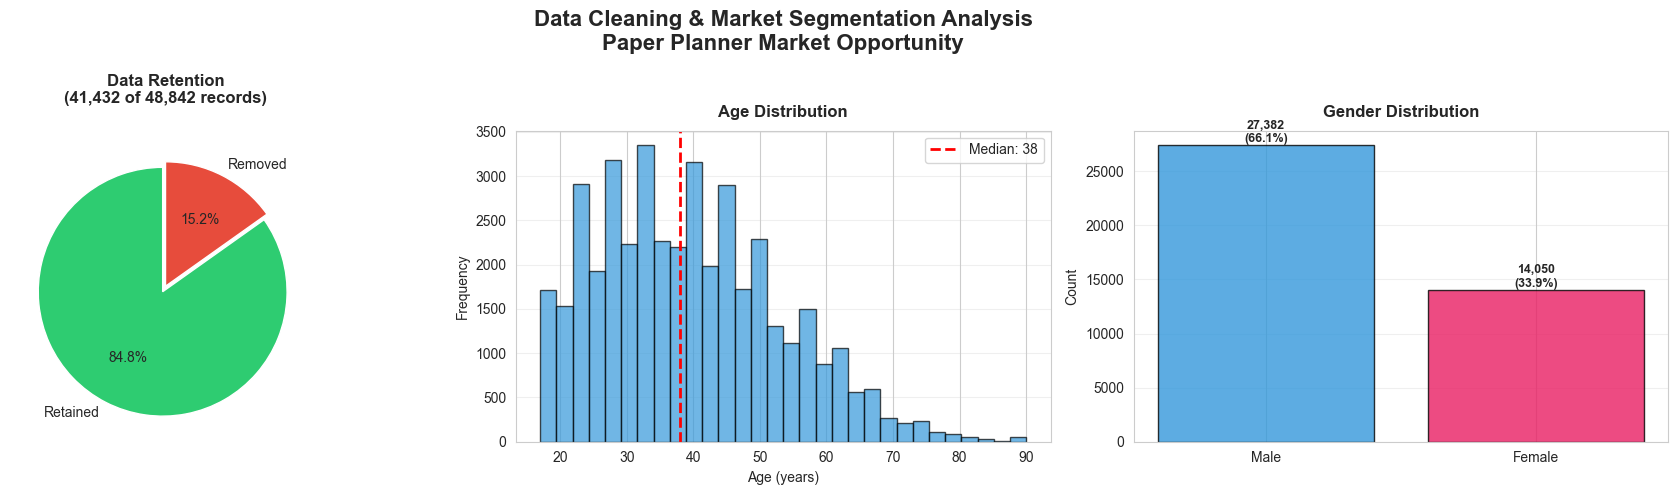

In [33]:
# 4. Data Cleaning Visualization

def visualize_cleaning_results(df_cleaned: pd.DataFrame, rows_before: int, rows_after: int) -> None:
    """
    Create visualizations: Data Retention, Age Distribution, Gender Distribution.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Data Retention Pie Chart
    rows_removed = rows_before - rows_after
    retention_data = [rows_after, rows_removed]
    colors = ['#2ecc71', '#e74c3c']
    explode = (0.05, 0)
    axes[0].pie(retention_data, labels=['Retained', 'Removed'], autopct='%1.1f%%',
                colors=colors, explode=explode, startangle=90, textprops={'fontsize': 10})
    axes[0].set_title(f'Data Retention\n({rows_after:,} of {rows_before:,} records)', 
                     fontsize=12, fontweight='bold', pad=20)

    # 2. Age Distribution
    axes[1].hist(df_cleaned['age'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[1].axvline(df_cleaned['age'].median(), color='red', linestyle='--', 
                    linewidth=2, label=f"Median: {df_cleaned['age'].median():.0f}")
    axes[1].set_xlabel('Age (years)', fontsize=10)
    axes[1].set_ylabel('Frequency', fontsize=10)
    axes[1].set_title('Age Distribution', fontsize=12, fontweight='bold', pad=10)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    # 3. Gender Distribution
    gender_counts = df_cleaned['sex'].value_counts()
    colors_gender = ['#3498db', '#e91e63']
    bars = axes[2].bar(gender_counts.index, gender_counts.values, color=colors_gender, 
                       edgecolor='black', alpha=0.8)
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height):,}\n({height/len(df_cleaned)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[2].set_ylabel('Count', fontsize=10)
    axes[2].set_title('Gender Distribution', fontsize=12, fontweight='bold', pad=10)
    axes[2].grid(axis='y', alpha=0.3)

    # Main Title
    fig.suptitle('Data Cleaning & Market Segmentation Analysis\nPaper Planner Market Opportunity', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()

# Call the visualization function AFTER cleaning
# Capture rows BEFORE and AFTER cleaning from the pipeline
rows_before = len(df)  # Original dataset size
rows_after = len(df_cleaned)  # Cleaned dataset size
visualize_cleaning_results(df_cleaned, rows_before, rows_after)

In [44]:
# 5. Validate Cleaned Data

def validate_cleaned_data(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Validate the cleaned dataset to ensure data quality.
   """ 
    print("5. CLEANING VALIDATION\n")
    
    validation = {
        'missing_values': df.isnull().sum().sum(),
        'duplicate_rows': df.duplicated().sum(),
        'shape': df.shape,
        'columns': list(df.columns)
    }
    
    print(f"✓ Final dataset shape: {validation['shape']}")
    print(f"✓ Total missing values: {validation['missing_values']}")
    print(f"✓ Duplicate rows: {validation['duplicate_rows']}")
    # Check for whitespace issues in categorical columns
    print(f"✓ Categorical columns for whitespace issues:")
    
    has_whitespace = False
    
    for col in df.select_dtypes(include='object').columns:
        # Use raw string for regex pattern
        whitespace_count = df[col].str.contains(r'^\s|\s$', regex=True, na=False).sum()
        if whitespace_count > 0:
            print(f" {col} has {whitespace_count} values with whitespace")
            has_whitespace = True
    
    if not has_whitespace:
        print("   No whitespace issues found")
    
    # Display cleaned data sample
    print(f"\n  CLEANED DATASET SAMPLE  ")
    display(df.head(10))
    
    return validation

# Execute validation
validation_results = validate_cleaned_data(df_cleaned)

5. CLEANING VALIDATION

✓ Final dataset shape: (41432, 14)
✓ Total missing values: 0
✓ Duplicate rows: 0
✓ Categorical columns for whitespace issues:
   No whitespace issues found

  CLEANED DATASET SAMPLE  


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0
5,37,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,0
6,49,Private,9th,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K,0
7,52,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K,1
8,31,Private,Masters,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K,1
9,42,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K,1


In [45]:
# Save cleaned dataset for EDA
df_cleaned.to_csv('/Users/mgarzon/Desktop/Statistics/FinalProject/ai-masters-stats-probability/Untitled/notebooks/df_cleaned.csv', index=False)
print("✓ Cleaned dataset exported to CSV")

✓ Cleaned dataset exported to CSV
